In [1]:
#import libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
#load dataset

df = pd.read_csv('/content/goodreads_data.csv', on_bad_lines='skip', engine='python')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 8)


,Unnamed: 0,Book,Author,Description,Genres,Avg_Rating,Num_Ratings,URL
0,0,To Kill a Mockingbird,Harper Lee,The unforgettable novel of a childhood in a sl...,"['Classics', 'Fiction', 'Historical Fiction', ...",4.27,"5,691,311",https://www.goodreads.com/book/show/2657.To_Ki...
1,1,Harry Potter and the Philosopher’s Stone (Harr...,J.K. Rowling,Harry Potter thinks he is an ordinary boy - un...,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',...",4.47,"9,278,135",https://www.goodreads.com/book/show/72193.Harr...
2,2,Pride and Prejudice,Jane Austen,"Since its immediate success in 1813, Pride and...","['Classics', 'Fiction', 'Romance', 'Historical...",4.28,"3,944,155",https://www.goodreads.com/book/show/1885.Pride...
3,3,The Diary of a Young Girl,Anne Frank,Discovered in the attic in which she spent the...,"['Classics', 'Nonfiction', 'History', 'Biograp...",4.18,"3,488,438",https://www.goodreads.com/book/show/48855.The_...
4,4,Animal Farm,George Orwell,Librarian's note: There is an Alternate Cover ...,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',...",3.98,"3,575,172",https://www.goodreads.com/book/show/170448.Ani...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   10000 non-null  int64  
 1   Book         10000 non-null  object 
 2   Author       10000 non-null  object 
 3   Description  9923 non-null   object 
 4   Genres       10000 non-null  object 
 5   Avg_Rating   10000 non-null  float64
 6   Num_Ratings  10000 non-null  object 
 7   URL          10000 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


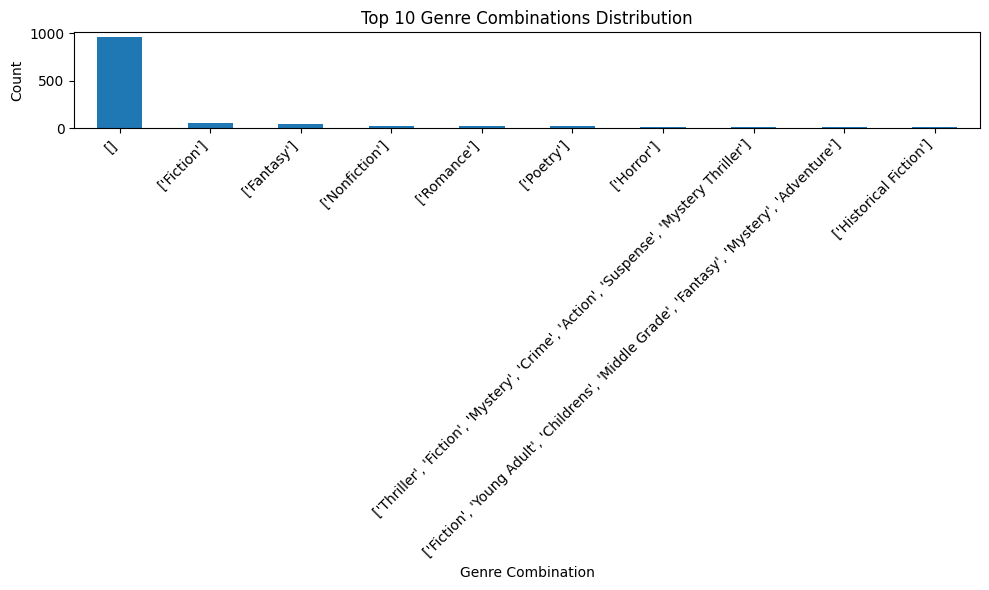

In [4]:
# Genre distribution
plt.figure(figsize=(10, 6))
df['Genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genre Combinations Distribution")
plt.xlabel("Genre Combination")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

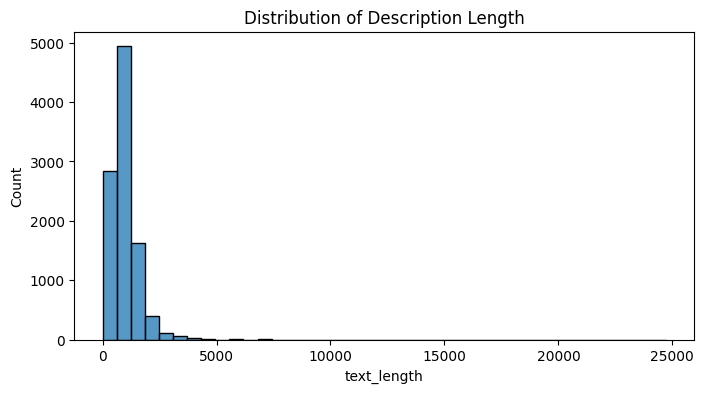

In [5]:
#Length of text feature
df["text_length"] = df["Description"].astype(str).apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(df["text_length"], bins=40)
plt.title("Distribution of Description Length")
plt.show()

In [6]:
df["text"] = df["Genres"].astype(str) + " " + df["Description"].astype(str)


In [7]:
# 2. Data Preprocessing (Text Cleaning)
import re
import string
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Performs essential text cleaning steps (Lowercasing, Punctuation, Stopwords)."""
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

# Apply the cleaning function to the 'Description' column
df['Clean Summary'] = df['Description'].apply(clean_text)
print("\nText Preprocessing Complete.")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



Text Preprocessing Complete.


In [8]:
df['text']

,text
0,"['Classics', 'Fiction', 'Historical Fiction', ..."
1,"['Fantasy', 'Fiction', 'Young Adult', 'Magic',..."
2,"['Classics', 'Fiction', 'Romance', 'Historical..."
3,"['Classics', 'Nonfiction', 'History', 'Biograp..."
4,"['Classics', 'Fiction', 'Dystopia', 'Fantasy',..."
...,...
9995,"['Dystopia', 'Science Fiction', 'Post Apocalyp..."
9996,[] Jeth Cavanaugh is searching for a new life ...
9997,"['Fiction', 'Horror', 'Dystopia', 'Coming Of A..."
9998,"['New Adult', 'Romance', 'Contemporary Romance..."


In [26]:
from sklearn.preprocessing import LabelEncoder
import ast

# Convert the string representation of lists in 'Genres' to actual lists
df['Genre_List'] = df['Genres'].apply(ast.literal_eval)

# Extract the first genre; if the list is empty, assign 'Unknown'
df['Primary_Genre'] = df['Genre_List'].apply(lambda x: x[0] if x else 'Unknown')

# Identify top N genres and group the rest into 'Other'
N = 50 # Number of top genres to keep
top_genres = df['Primary_Genre'].value_counts().nlargest(N).index.tolist()
df['Simplified_Genre'] = df['Primary_Genre'].apply(lambda x: x if x in top_genres else 'Other')

# Encode the simplified primary genre to numerical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Simplified_Genre'])

In [10]:
y

array([ 7, 12,  7, ..., 14, 25, 46])

In [11]:
#TF-IDF vectorize
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X = tfidf.fit_transform(df["Genres"].astype(str) + " " + df["Clean Summary"])

In [12]:
#train_test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
#model train(LogisticRegression)
log_reg = LogisticRegression(max_iter=300)
log_reg.fit(X_train, y_train)

log_preds = log_reg.predict(X_test)

log_acc = accuracy_score(y_test, log_preds) * 100
print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 60.550000000000004


In [14]:
#model train(SVM)

svm_model = SVC()
svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_preds) * 100
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 60.4


In [15]:
#model train(Nave Bayes)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, nb_preds) * 100
print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 40.150000000000006


In [16]:
#model train(Randoom Forest)

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds) * 100
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 63.6


In [17]:
#Hyperparameter Tuning (GridSearchCV)

print("\n\n===== Running GridSearchCV (May take time)… =====\n")

# --- SVM Tuning ---
# Reduced 'C' values to speed up GridSearchCV for demonstration.
# For a more thorough search, a wider range of 'C' values could be used.
svm_params = {
    "C": [1],
    "kernel": ["linear"]
}
svm_grid = GridSearchCV(SVC(), svm_params, cv=3, n_jobs=-1)
svm_grid.fit(X_train, y_train)



===== Running GridSearchCV (May take time)… =====



GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [1], 'kernel': ['linear']})

In [18]:
# --- Random Forest Tuning ---
# Reduced 'n_estimators' and 'max_depth' values to speed up GridSearchCV for demonstration.
# For a more thorough search, a wider range of values could be used.
rf_params = {
    "n_estimators": [100],
    "max_depth": [10]
}
rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10], 'n_estimators': [100]})

In [19]:
# --- Logistic Regression Tuning ---
log_params = {
    "C": [0.1, 1, 10]
}
log_grid = GridSearchCV(LogisticRegression(max_iter=300), log_params, cv=3, n_jobs=-1)
log_grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(max_iter=300), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10]})

In [20]:
# Save tuned models
tuned_models = {
    "SVM Tuned": svm_grid.best_estimator_,
    "Random Forest Tuned": rf_grid.best_estimator_,
    "Logistic Regression Tuned": log_grid.best_estimator_,
    "Naive Bayes": MultinomialNB()
}

tuned_results = {}

for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    tuned_results[name] = acc
    print(f"\n===== {name} (TUNED MODEL) =====")
    print("Accuracy:", acc)
    print(classification_report(y_test, preds))


===== SVM Tuned (TUNED MODEL) =====
Accuracy: 65.5
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       1.00      0.05      0.09        21
           2       0.82      0.56      0.67        25
           3       0.00      0.00      0.00         6
           4       0.55      0.33      0.41        18
           5       0.71      0.75      0.73        16
           6       0.50      0.17      0.25         6
           7       0.63      0.50      0.56       106
           8       0.67      0.18      0.29        11
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         1
          12       0.75      0.83      0.79       182
          13       0.00      0.00      0.00         2
          14       0.63      0.77      0.69       364
          15       0.60      0.75      0.67         4
          16       0.66      0.68      0.67       102
          17       0.75      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== Random Forest Tuned (TUNED MODEL) =====
Accuracy: 45.65
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00        21
           2       1.00      0.24      0.39        25
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        18
           5       0.00      0.00      0.00        16
           6       0.00      0.00      0.00         6
           7       0.50      0.01      0.02       106
           8       0.00      0.00      0.00        11
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         1
          12       0.59      0.85      0.70       182
          13       0.00      0.00      0.00         2
          14       0.36      0.97      0.53       364
          15       0.00      0.00      0.00         4
          16       1.00      0.02      0.04       102
          17      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



===== Logistic Regression Tuned (TUNED MODEL) =====
Accuracy: 63.9
              precision    recall  f1-score   support

           0       1.00      0.25      0.40         4
           1       1.00      0.10      0.17        21
           2       0.67      0.48      0.56        25
           3       0.00      0.00      0.00         6
           4       0.64      0.39      0.48        18
           5       0.77      0.62      0.69        16
           6       0.00      0.00      0.00         6
           7       0.59      0.49      0.54       106
           8       0.50      0.09      0.15        11
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         1
          12       0.73      0.86      0.79       182
          13       0.00      0.00      0.00         2
          14       0.63      0.77      0.69       364
          15       0.67      0.50      0.57         4
          16       0.70      0.65      0.67       102
          17 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m



 BEST MODEL: SVM Tuned
Accuracy: 65.5


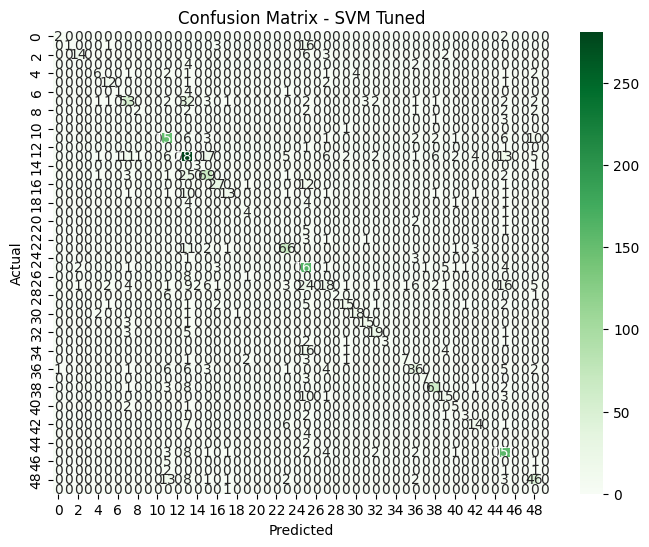

In [21]:
#Best Model + Confusion Matrix
best_model_name = max(tuned_results, key=tuned_results.get)
best_model = tuned_models[best_model_name]

print("\n\n BEST MODEL:", best_model_name)
print("Accuracy:", tuned_results[best_model_name])

best_preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

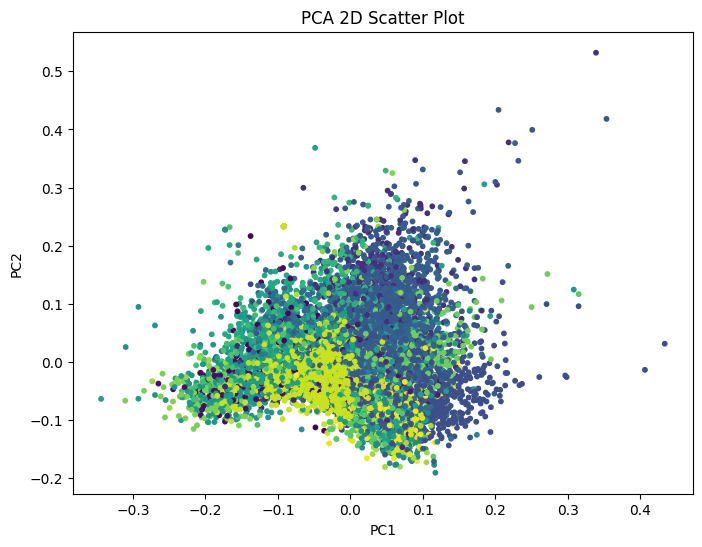

In [22]:
#scatter
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=10)
plt.title("PCA 2D Scatter Plot")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

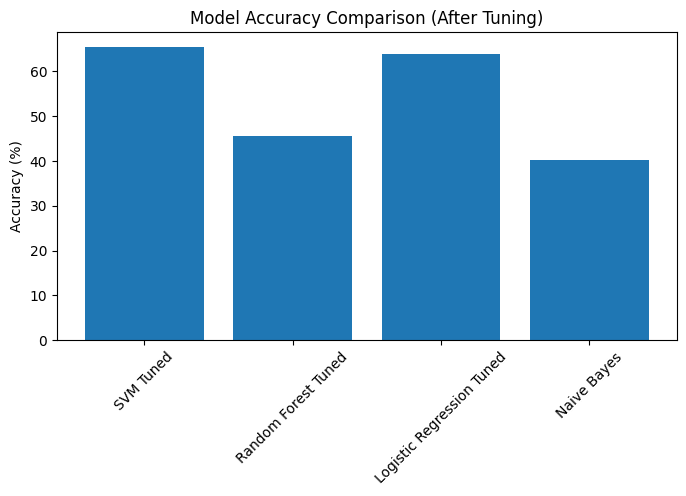

In [23]:
#Model Accuracy Comparison
plt.figure(figsize=(8, 4))
plt.bar(tuned_results.keys(), tuned_results.values())
plt.title("Model Accuracy Comparison (After Tuning)")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.show()

In [24]:
#classification report
print("\nClassification Report:")
print(classification_report(y_test, best_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       1.00      0.05      0.09        21
           2       0.82      0.56      0.67        25
           3       0.00      0.00      0.00         6
           4       0.55      0.33      0.41        18
           5       0.71      0.75      0.73        16
           6       0.50      0.17      0.25         6
           7       0.63      0.50      0.56       106
           8       0.67      0.18      0.29        11
          10       0.00      0.00      0.00         4
          11       0.00      0.00      0.00         1
          12       0.75      0.83      0.79       182
          13       0.00      0.00      0.00         2
          14       0.63      0.77      0.69       364
          15       0.60      0.75      0.67         4
          16       0.66      0.68      0.67       102
          17       0.75      0.66      0.70        41
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
#model comparison
print("\nModel Comparison:")
comparison_df = pd.DataFrame.from_dict(tuned_results, orient='index', columns=['Accuracy'])
print(comparison_df)


Model Comparison:
                           Accuracy
SVM Tuned                     65.50
Random Forest Tuned           45.65
Logistic Regression Tuned     63.90
Naive Bayes                   40.15
